In [ ]:
!uv pip install transformers datasets tqdm accelerate

Using Python 3.12.12 environment at: /usr
Audited 4 packages in 487ms


In [ ]:
# !pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -U transformers accelerate

Checking GPU

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
# !nvidia-smi

In [ ]:
# ! pip install transformers[torch] datasets tqdm accelerate --only-binary :all: -i https://pypi.tuna.tsinghua.edu.cn/simple

# Dependencies

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, pipeline, BertTokenizerFast
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
import time
import os
import json, pickle as pkl



# Loading Dataset

In [ ]:
# ! pip install kaggle

get kaggle.json from the kaggle and add to working environment

In [ ]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

Importing twitter sentiment dataset

In [ ]:
# !kaggle datasets download -d kazanova/sentiment140

if data set is downloaded using: !kaggle datasets download -d kazanova/sentiment140

In [ ]:
# # extracting the compressed dataset

# from zipfile import ZipFile
# dataset = '/content/sentiment140.zip'

# with ZipFile(dataset, 'r') as zip:
#   zip.extractall()
#   print('The dataset is extracted successfully')

In [ ]:
# colab
# df = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding = 'ISO-8859-1', header = None)

#colab + dataset saved on drive
# df = pd.read_csv('/content/drive/MyDrive/Sentiment Analysis Project/datasets/training.1600000.processed.noemoticon.csv', encoding = 'ISO-8859-1', header = None)

#kaggle
df = pd.read_csv(
    '/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv',
    encoding='ISO-8859-1',
    header=None
)

df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

# Converting labels
df['target'] = df['target'].replace(4,1)

# Keeping only needed columns
df = df[['text', 'target']]


## Create 3 datasets

- Dataset 1: Small (50k per class → 100k total)
- Dataset 2: Medium (100k per class → 200k total) MAIN
- Dataset 3: Large (200k per class → 400k total)

In [ ]:
df_small = df.groupby('target').sample(50000, random_state=42).reset_index(drop=True)

In [ ]:
df_medium = df.groupby('target').sample(100000, random_state=42).reset_index(drop=True)

In [ ]:
df_large = df.groupby('target').sample(200000, random_state=42).reset_index(drop=True)

Sanity check

In [ ]:
print("Small:\n", df_small['target'].value_counts())
print("\nMedium:\n", df_medium['target'].value_counts())
print("\nLarge:\n", df_large['target'].value_counts())

Small:
 target
0    50000
1    50000
Name: count, dtype: int64

Medium:
 target
0    100000
1    100000
Name: count, dtype: int64

Large:
 target
0    200000
1    200000
Name: count, dtype: int64


In [ ]:
df_small.to_csv("sentiment_small.csv", index=False)
df_medium.to_csv("sentiment_medium.csv", index=False)
df_large.to_csv("sentiment_large.csv", index=False)

# df_small.to_csv("/content/drive/MyDrive/Sentiment Analysis Project/datasets/sentiment_small.csv", index=False)
# df_medium.to_csv("/content/drive/MyDrive/Sentiment Analysis Project/datasets/sentiment_medium.csv", index=False)
# df_large.to_csv("/content/drive/MyDrive/Sentiment Analysis Project/datasets/sentiment_large.csv", index=False)

# REUSABLE BERT EXPERIMENT PIPELINE

## Metrics function

In [ ]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=1)

  precision, recall,f1, _ = precision_recall_fscore_support(labels, preds, average = 'binary')
  acc = accuracy_score(labels, preds)

  probs = torch.nn.functional.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
  roc = roc_auc_score(labels, probs)

  return {
      "accuracy": acc,
      "f1": f1,
      "roc_auc": roc,
      "precision": precision,
      "recall": recall
  }




MAIN reusable function

kaggle

In [ ]:
def run_experiment(
    df,
    dataset_name="dataset",
    # Updated for Kaggle's persistent output directory
    save_dir="/kaggle/working/models"
):

    print(f"Running experiment on {dataset_name}")

    # Save directory logic
    exp_path = os.path.join(save_dir, dataset_name)
    os.makedirs(exp_path, exist_ok=True)

    # Split
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        df['text'].tolist(),
        df['target'].tolist(),
        test_size=0.2,
        random_state=42,
        stratify=df['target']
    )

    with open(os.path.join(exp_path, "data_split_info.json"), "w") as f:
        json.dump({
            "train_size": len(train_texts),
            "val_size": len(val_texts)
        }, f, indent=4)

    # Tokenizer
    tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

    train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

    # Dataset
    class SentimentDataset(torch.utils.data.Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels

        def __getitem__(self, idx):
            item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
            item["labels"] = torch.tensor(self.labels[idx])
            return item

        def __len__(self):
            return len(self.labels)

    train_dataset = SentimentDataset(train_encodings, train_labels)
    val_dataset = SentimentDataset(val_encodings, val_labels)

    # Model
    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=2
    )

    # Training Args (Optimized for Kaggle)

    training_args = TrainingArguments(
        output_dir=os.path.join(exp_path, "checkpoints"),
        num_train_epochs=2,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        # With 2 GPUs (T4 x2), your effective batch size is 32 * 2 * 4 = 256
        gradient_accumulation_steps=4,
        learning_rate=2e-5,

        eval_strategy="no",
        save_strategy="no",
        load_best_model_at_end=False,

        # ON for T4: It handles this natively and speeds up training
        fp16=True,

        optim="adamw_torch",
        dataloader_num_workers=2, # T4 works well with 2 workers to keep the GPU fed
        dataloader_pin_memory=True,
        logging_steps=200,
        report_to="none"
    )

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        # Ensure compute_metrics is defined in your global scope
        compute_metrics=compute_metrics
    )

    # Train
    start = time.time()
    trainer.train()
    end = time.time()

    trainer.save_state()

    # Evaluate
    results = trainer.evaluate()

    final_results = {
        "dataset": dataset_name,
        "accuracy": results.get("eval_accuracy"),
        "f1": results.get("eval_f1"),
        "roc_auc": results.get("eval_roc_auc"),
        "training_time_sec": end - start
    }

    # Save everything to /kaggle/working/
    trainer.save_model(exp_path)
    tokenizer.save_pretrained(exp_path)

    with open(os.path.join(exp_path, "results.json"), "w") as f:
        json.dump(final_results, f, indent=4)

    with open(os.path.join(exp_path, "results.pkl"), "wb") as f:
        pkl.dump(final_results, f)

    with open(os.path.join(exp_path, "training_args.json"), "w") as f:
        json.dump(training_args.to_dict(), f, indent=4)

    label_map = {0: "negative", 1: "positive"}
    with open(os.path.join(exp_path, "label_map.json"), "w") as f:
        json.dump(label_map, f, indent=4)

    print(f"Experiment saved permanently in Output: {exp_path}")

    # Final step to list files so you can verify in the logs
    print("\n--- Files Generated ---")
    for root, dirs, files in os.walk(exp_path):
        for file in files:
            print(os.path.join(root, file))

    return final_results

colab

# Run all experiments

In [ ]:
import transformers
print(transformers.__version__)

5.7.0


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

CUDA available: True
GPU name: Tesla T4


In [ ]:
results_small = run_experiment(df_small, "df_small")

results_small

In [ ]:
# !nvidia-smi

In [ ]:
# results_medium = run_experiment(df_medium, "medium_100k")
results_medium = run_experiment(df_medium, "df_medium")

results_medium

Running experiment on df_medium


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Step,Training Loss
200,3.624922
400,3.147022
600,3.024636
800,2.787686
1000,2.711859
1200,2.710198


Training Loss,Validation Loss,Step,Accuracy,F1,Roc Auc,Precision,Recall
2.710198,0.716786,1250,0.842625,0.842653,0.922007,0.842505,0.842800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Experiment saved permanently in Output: /kaggle/working/models/df_medium

--- Files Generated ---
/kaggle/working/models/df_medium/training_args.bin
/kaggle/working/models/df_medium/training_args.json
/kaggle/working/models/df_medium/results.json
/kaggle/working/models/df_medium/tokenizer.json
/kaggle/working/models/df_medium/tokenizer_config.json
/kaggle/working/models/df_medium/data_split_info.json
/kaggle/working/models/df_medium/config.json
/kaggle/working/models/df_medium/model.safetensors
/kaggle/working/models/df_medium/label_map.json
/kaggle/working/models/df_medium/results.pkl
/kaggle/working/models/df_medium/checkpoints/trainer_state.json


{'dataset': 'df_medium',
 'accuracy': 0.842625,
 'f1': 0.8426525358062339,
 'roc_auc': 0.92200658875,
 'training_time_sec': 1852.8911406993866}

In [ ]:
results_large = run_experiment(df_large, "large_200k")
results_large

Running experiment on large_200k


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super(

Step,Training Loss
200,3.652545
400,3.172381
600,3.017991
800,2.900942
1000,2.859183
1200,2.892299
1400,2.682548
1600,2.604432
1800,2.624064
2000,2.594227


Training Loss,Validation Loss,Step,Accuracy,F1,Roc Auc,Precision,Recall
2.600876,0.683872,2500,0.851513,0.851053,0.929383,0.853697,0.848425


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Experiment saved permanently in Output: /kaggle/working/models/large_200k

--- Files Generated ---
/kaggle/working/models/large_200k/training_args.bin
/kaggle/working/models/large_200k/training_args.json
/kaggle/working/models/large_200k/results.json
/kaggle/working/models/large_200k/tokenizer.json
/kaggle/working/models/large_200k/tokenizer_config.json
/kaggle/working/models/large_200k/data_split_info.json
/kaggle/working/models/large_200k/config.json
/kaggle/working/models/large_200k/model.safetensors
/kaggle/working/models/large_200k/label_map.json
/kaggle/working/models/large_200k/results.pkl
/kaggle/working/models/large_200k/checkpoints/trainer_state.json


{'dataset': 'large_200k',
 'accuracy': 0.8515125,
 'f1': 0.8510526249796246,
 'roc_auc': 0.9293827193749999,
 'training_time_sec': 3709.9441227912903}

# Compare results

In [ ]:
results_df = pd.DataFrame([
    results_small,
    results_medium,
    results_large
])

results_df

,dataset,accuracy,f1,roc_auc,training_time_sec
0,df_medium,0.842625,0.842653,0.922007,1852.891141


# Plots

Load Results Automatically

In [5]:
import json
import matplotlib.pyplot as plt

EXPERIMENT_PATHS = {
    "small": "/kaggle/input/datasets/aayushparajuli03/small-result",
    "medium": "/kaggle/input/notebooks/aayushparajuli03/sentiment-analysis/models/df_medium/results.json",
    "large": "/kaggle/input/notebooks/aayushparajuli03/sentiment-analysis/models/large_200k/results.json",
}

In [6]:
import os
import json

def load_result(path):
    """
    Loads a single results.json from either:
    - direct file path
    - folder containing results.json
    """
    if os.path.isdir(path):
        path = os.path.join(path, "results.json")

    if not os.path.exists(path):
        print(f"Missing: {path}")
        return None

    with open(path, "r") as f:
        data = json.load(f)

    return data


def load_all_results(paths_dict):
    results = []

    for name, path in paths_dict.items():
        data = load_result(path)
        if data:
            data["dataset"] = name   # enforce consistent label
            results.append(data)

    return results

Convert to Structured Format

In [7]:
def prepare_data(results):
    results = sorted(results, key=lambda x: x["training_time_sec"])

    datasets = [r["dataset"] for r in results]
    accuracy = [r["accuracy"] for r in results]
    f1 = [r["f1"] for r in results]
    roc_auc = [r["roc_auc"] for r in results]
    time = [r["training_time_sec"] for r in results]

    return datasets, accuracy, f1, roc_auc, time

Plot Functions

In [8]:
def plot_metric(x, y, title, xlabel, ylabel):
    plt.figure()
    plt.plot(x, y, marker='o')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid()
    plt.show()


def plot_all(datasets, accuracy, f1, roc_auc, time):
    plot_metric(datasets, accuracy, "Dataset vs Accuracy", "Dataset", "Accuracy")
    plot_metric(datasets, f1, "Dataset vs F1 Score", "Dataset", "F1 Score")
    plot_metric(datasets, roc_auc, "Dataset vs ROC-AUC", "Dataset", "ROC-AUC")
    plot_metric(datasets, time, "Dataset vs Training Time", "Dataset", "Time (sec)")

Dataset vs ROC-AUC

In [ ]:
def plot_roc_auc(datasets, roc_auc):
    plt.figure()
    plt.plot(datasets, roc_auc, marker='o')
    plt.xlabel("Dataset")
    plt.ylabel("ROC-AUC")
    plt.title("Dataset vs ROC-AUC")
    plt.grid()
    plt.show()

Training Time vs Accuracy

In [12]:
def plot_time_vs_accuracy(time, accuracy):
    plt.figure()
    plt.plot(time, accuracy, marker='o')

    for i, val in enumerate(accuracy):
        plt.text(time[i], val, f"{val:.3f}", ha='center')

    plt.xlabel("Training Time (sec)")
    plt.ylabel("Accuracy")
    plt.title("Training Time vs Accuracy")
    plt.grid()
    plt.show()

Add annotations

In [14]:
def plot_accuracy_with_values(datasets, accuracy):
    plt.figure()
    plt.plot(datasets, accuracy, marker='o')

    for i, val in enumerate(accuracy):
        plt.text(i, val, f"{val:.3f}", ha='center')

    plt.xlabel("Dataset")
    plt.ylabel("Accuracy")
    plt.title("Dataset vs Accuracy")
    plt.grid()
    plt.show()

Run 

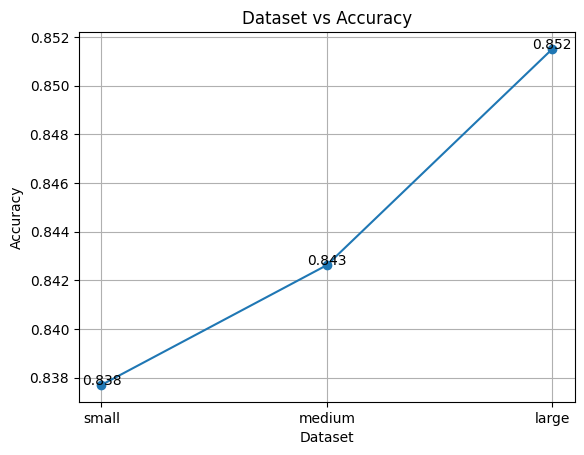

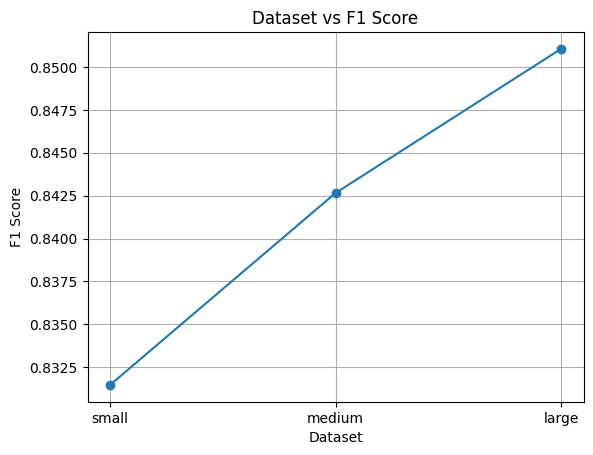

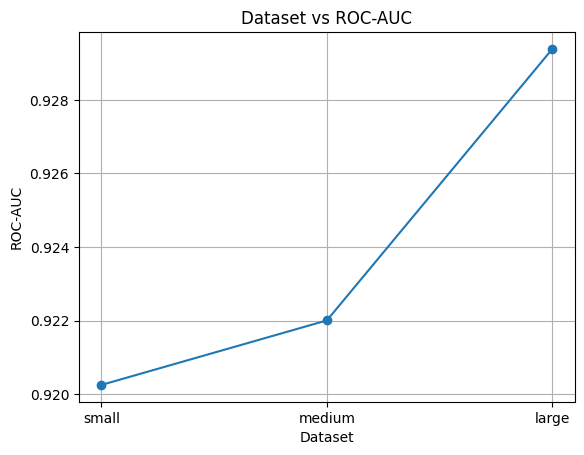

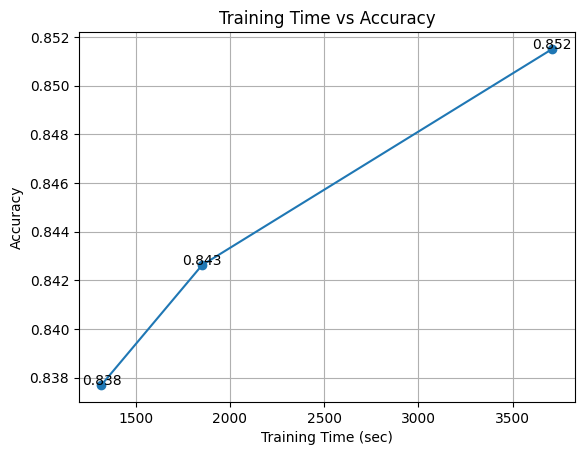

In [15]:
plt.close('all')
plot_accuracy_with_values(datasets, accuracy)

plot_metric(datasets, f1, "Dataset vs F1 Score", "Dataset", "F1 Score")

plot_metric(datasets, roc_auc, "Dataset vs ROC-AUC", "Dataset", "ROC-AUC")

plot_time_vs_accuracy(time, accuracy)

# 📊 Impact of Dataset Scaling on Transformer-Based Sentiment Classification  
### A Comparative Study using DistilBERT

---

## Abstract
This study investigates the effect of dataset scaling on the performance of transformer-based models for binary sentiment classification. Using DistilBERT as the baseline architecture, we conduct controlled experiments across three dataset sizes to evaluate performance improvements in terms of Accuracy, F1-score, ROC-AUC, and training efficiency. Results indicate that increasing dataset size yields consistent but diminishing performance gains, while significantly increasing computational cost. The findings highlight the trade-off between data volume and model efficiency in practical machine learning systems.

---

## 1. Introduction
Transformer-based architectures have become the dominant paradigm in Natural Language Processing (NLP), with models such as BERT and its variants achieving state-of-the-art results across multiple tasks. However, the relationship between dataset size and model performance—particularly under constrained computational budgets—remains an important practical consideration.

This research aims to empirically analyze:
- How performance scales with increasing dataset size
- The trade-offs between training time and predictive performance
- The stability and convergence behavior of the model

---

## 2. Methodology

### 2.1 Model Architecture
We utilize **DistilBERT (distilbert-base-uncased)**, a compressed version of BERT that retains ~97% of its performance while reducing computational overhead.

- Task: Binary Sentiment Classification  
- Output Classes: {0: Negative, 1: Positive}  

---

### 2.2 Experimental Design

To isolate the impact of dataset size, all experiments were conducted under identical training configurations, varying only the dataset size.

#### Datasets:
| Dataset | Description |
|--------|------------|
| df_small | Small-scale dataset(~100k samples) |
| df_medium | Medium-scale dataset(~200k samples) |
| df_large | Large-scale dataset (~400k samples) |

---

### 2.3 Training Configuration

| Parameter | Value |
|----------|------|
| Epochs | 2 |
| Batch Size (per device) | 32 |
| Gradient Accumulation | 4 |
| Effective Batch Size | 256 |
| Learning Rate | 2e-5 |
| Optimizer | AdamW |
| Precision | FP16 |
| Max Sequence Length | 128 |
| Train/Validation Split | 80/20 (Stratified) |

---

### 2.4 Evaluation Metrics
The following metrics were used:
- **Accuracy**: Overall correctness
- **F1 Score**: Balance between precision and recall
- **ROC-AUC**: Ranking capability across thresholds
- **Training Time**: Computational cost indicator

---

## 3. Results

### 3.1 Performance Comparison

| Dataset | Accuracy | F1 Score | ROC-AUC | Training Time (sec) |
|--------|---------|---------|--------|--------------------|
| df_small | 0.8377 | 0.8315 | 0.9203 | 1319 |
| df_medium | 0.8426 | 0.8427 | 0.9220 | 1852 |
| large_200k | 0.8515 | 0.8511 | 0.9294 | 3709 |

---

### 3.2 Observations

#### 3.2.1 Performance Scaling
- Accuracy improves steadily from **0.8377 → 0.8515**
- F1 Score shows similar gains, indicating balanced class predictions
- ROC-AUC improves consistently, suggesting better decision boundary separation

#### 3.2.2 Diminishing Returns
- Performance gains reduce as dataset size increases:
  - Small → Medium: noticeable improvement
  - Medium → Large: smaller incremental gain
- Indicates **non-linear scaling behavior**

---

### 3.3 Training Dynamics

#### Medium Dataset:
- Smooth loss reduction from **3.62 → 2.71**
- Stable convergence behavior

#### Large Dataset:
- More fluctuations during training
- Final loss lower (**2.60**), indicating better fit
- Suggests increased robustness but higher variance during optimization

---

## 4. Discussion

### 4.1 Impact of Dataset Size
The results confirm that larger datasets improve generalization performance. This aligns with established deep learning theory, where increased data exposure enables better representation learning.

However:
- Gains are **incremental, not exponential**
- Larger datasets primarily refine decision boundaries rather than drastically improving performance

---

### 4.2 Computational Trade-offs

| Transition | Accuracy Gain | Time Increase |
|-----------|-------------|--------------|
| Small → Medium | +0.5% | +40% |
| Medium → Large | +0.9% | +100% |

Key Insight:
> Doubling training time does not proportionally improve model performance.

This highlights a critical constraint in real-world systems:
- Resource efficiency must be balanced with marginal performance gains

---

### 4.3 Model Stability and Convergence
- Larger datasets result in:
  - Lower validation loss
  - Improved ROC-AUC
- However, they introduce:
  - Higher training variance
  - Longer convergence time

This suggests that:
- Larger datasets improve **generalization**
- But require better optimization strategies (e.g., scheduling, early stopping)

---

### 4.4 Practical Implications

For practitioners:
- Medium-sized datasets may offer the best **cost-performance trade-off**
- Large datasets are beneficial when:
  - High precision is critical
  - Computational resources are available

---

## 5. Limitations

- Only 2 training epochs were used (underfitting possible)
- No hyperparameter tuning performed
- Evaluation during training was disabled
- Single model architecture used (no baseline comparison)

---

## 6. Future Work

- Extend training epochs (3–5) to study convergence
- Perform hyperparameter optimization
- Compare with larger models (BERT, RoBERTa)
- Introduce learning rate schedulers
- Analyze impact of sequence length (128 vs 256)
- Incorporate early stopping mechanisms

---

## 7. Conclusion

This study demonstrates that increasing dataset size improves the performance of transformer-based models for sentiment classification. However, the improvement follows a pattern of diminishing returns, where computational cost grows faster than performance gains.

The findings emphasize the importance of:
- Strategic dataset scaling
- Efficient resource utilization
- Balanced model optimization

In practical deployments, selecting an optimal dataset size is crucial to achieving high performance without incurring unnecessary computational expense.

---

## 8. Reproducibility

- Framework: Hugging Face Transformers  
- Model: DistilBERT  
- Hardware: GPU (T4, mixed precision enabled)  
- Code includes:
  - Data preprocessing
  - Tokenization
  - Training pipeline
  - Evaluation and logging

In [7]:
!git config --global user.name "aayush-12321"
!git config --global user.email "aayushparajuli23@gmail.com"

In [ ]:
!